In [ ]:
# 데이터 분석 및 시각화에 필요한 기본 라이브러리들을 불러옵니다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn 라이브러리에서 필요한 모듈들을 불러옵니다.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


1.

In [ ]:
import tensorflow as tf

2.

In [ ]:
ad_df = pd.read_csv('4_ad_campaign_roi.csv')
ad_df.head()

,channel,cost_millions,duration_days,target_age,impressions,clicks,conversions,roi_percentage
0,검색광고,564.0,59.0,2030대,1051296.0,13865.0,1106.0,-77.92
1,TV,89.0,20.0,전체,111250.0,229.0,18.0,-106.58
2,라디오,62.0,76.0,2030대,153450.0,6102.0,174.0,-92.96
3,라디오,21.0,18.0,10대,23037.0,1007.0,12.0,-96.55
4,TV,971.0,90.0,4050대,1310850.0,62609.0,3036.0,-85.28


3.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import urllib.request

# 1. 인터넷에서 나눔고딕 폰트 파일을 현재 폴더로 직접 다운로드
font_url = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
urllib.request.urlretrieve(font_url, "my_nanum_font.ttf")

# 2. 다운로드한 폰트 파일의 경로 지정 및 이름 속성 가져오기
fe = fm.FontEntry(fname="my_nanum_font.ttf", name="MyNanum")
fm.fontManager.ttflist.insert(0, fe)  # Matplotlib 폰트 리스트 맨 앞에 강제 주입

# 3. 주입한 폰트 이름으로 전역 설정 변경 (마이너스 깨짐 방지도 함께)
plt.rc('font', family='MyNanum')
plt.rcParams['axes.unicode_minus'] = False

<Axes: xlabel='cost_millions', ylabel='roi_percentage'>

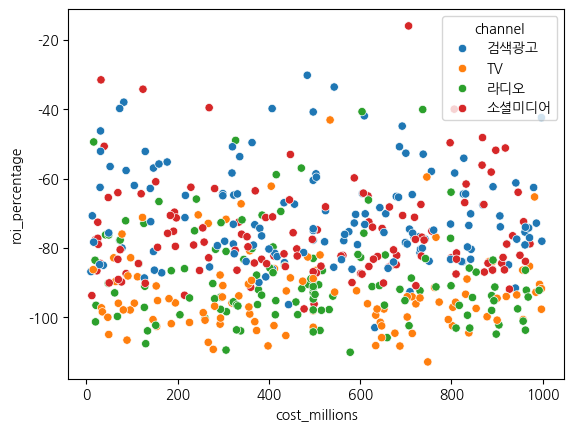

In [ ]:
sns.scatterplot(data=ad_df, x='cost_millions', y='roi_percentage', hue='channel')

4.

<Axes: xlabel='channel', ylabel='roi_percentage'>

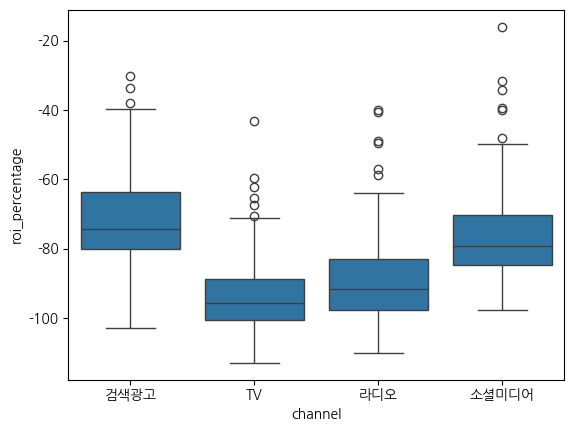

In [ ]:
sns.boxplot(data=ad_df, x='channel', y='roi_percentage')

In [ ]:
답안04='검색광고'

5.

In [ ]:
ad_df.groupby(['channel', 'target_age'])[['clicks', 'conversions']].mean()

clicks  conversions
channel target_age                           
TV      10대         19490.163622   891.508775
        2030대       30536.506721  1617.037579
        4050대       23593.051174  1138.007721
        전체          22613.200000   881.564570
검색광고    10대         31036.756819  1655.831070
        2030대       31869.008264  1502.430061
        4050대       26442.000000  1472.280374
        전체          22118.184072  1260.866667
라디오     10대         21372.138300  1355.200000
        2030대       22141.966415  1069.544574
        4050대       22608.329688  1543.260870
        전체          22377.281250  1085.812500
소셜미디어   10대         23496.846154  1438.091425
        2030대       26254.350000  1523.314541
        4050대       24430.833333  1265.933333
        전체          27572.661237  1739.483871

6.

In [ ]:
ad_pre = ad_df.copy()

ad_pre['cost_millions'].fillna(ad_pre['cost_millions'].median(), inplace=True)
ad_pre['duration_days'].fillna(ad_pre['duration_days'].median(), inplace=True)

/tmp/ipykernel_930/3801071918.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ad_pre['cost_millions'].fillna(ad_pre['cost_millions'].median(), inplace=True)
/tmp/ipykernel_930/3801071918.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

7.

In [ ]:
ad_pre['ctr'] = np.where(ad_pre['impressions']==0, 0, ad_pre['clicks'] / ad_pre['impressions'])

8.

In [ ]:
corr_list = ['channel', 'target_age']

ad_encoded = pd.get_dummies(data=ad_pre, columns=corr_list)

X = ad_encoded.drop(columns=['roi_percentage'])
y = ad_encoded['roi_percentage']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=2024)

9.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

10.

In [ ]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

LinearRegression()

11.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=2024)
model_rf.fit(X_train_scaled, y_train)

print(pd.DataFrame([model_rf.feature_importances_], columns=X.columns))

   cost_millions  duration_days  impressions    clicks  conversions      ctr  \
0       0.115679       0.025388     0.026929  0.031727     0.412599  0.10553   

   channel_TV  channel_검색광고  channel_라디오  channel_소셜미디어  target_age_10대  \
0    0.057189      0.097268     0.044664       0.070251        0.002463   

   target_age_2030대  target_age_4050대  target_age_전체  
0          0.004816          0.002371       0.003125  


In [ ]:
답안11='conversions'

12.

In [ ]:
lr_pred = model_lr.predict(X_valid_scaled)
rf_pred = model_rf.predict(X_valid_scaled)

print('lr')
print('mae', mean_absolute_error(y_valid, lr_pred))
print('r2', r2_score(y_valid, lr_pred))

print('rf')
print('mae', mean_absolute_error(y_valid, rf_pred))
print('r2', r2_score(y_valid, rf_pred))

lr
mae 5.834739670477766
r2 0.7722771714737284
rf
mae 5.496952048900376
r2 0.7834913203019329


13.

In [ ]:
# 아래의 코드를 실행해 주세요.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_absolute_error')

history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=16, validation_data=(X_valid_scaled, y_valid))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 81.0759 - val_loss: 82.4927
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 80.6566 - val_loss: 82.0539
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 80.0783 - val_loss: 81.2893
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 79.0571 - val_loss: 79.9570
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 77.2907 - val_loss: 77.7548
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 74.4467 - val_loss: 74.2814
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 69.9763 - val_loss: 69.0249
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 63.3488 - val_loss: 61.4304
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 54.1220 - val_loss: 51.2137
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 42.8221 - val_loss: 38.8681
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 31.3057 - val_loss: 27.8026
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1

14.

In [ ]:
# 아래 코드를 실행하여 시뮬레이션용 데이터를 생성하세요.
new_campaign_data = np.array([[500, 30, 1000000, 15000, 1000, 0.015, 1, 0, 0, 1, 0, 0, 1, 0]])

In [ ]:
new_campaign_data_scaled = scaler.transform(new_campaign_data)

predicted_roi_dl = model.predict(new_campaign_data_scaled)

print(predicted_roi_dl)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
[[-81.04839]]
